In [16]:
import pandas as pd
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV


file_path = 'df_train.csv'
df = pd.read_csv(file_path)
df



,date,symbol,open,close,low,high,volume
0,2010-01-04,ACTS,15.13,14.97,14.84,15.28,5459.882
1,2010-01-04,AMWD,7.00,7.12,6.98,7.14,92067.275
2,2010-01-04,ARV,18.27,18.31,18.12,18.47,38034.257
3,2010-01-04,BBY,3.11,3.11,3.09,3.13,40964.820
4,2010-01-04,BCDM,19.78,19.53,19.41,19.90,3646.991
...,...,...,...,...,...,...,...
100595,2013-12-31,XTG,20.15,20.00,20.15,20.15,42044.703
100596,2013-12-31,YPN,14.94,14.82,14.94,14.94,29030.106
100597,2013-12-31,YRD,3.40,3.39,3.40,3.40,11778.336
100598,2013-12-31,YVNL,4.25,4.24,4.25,4.25,6431.843


In [5]:
df_train = df.iloc[:int(len(df)*0.7)]
df_test = df.iloc[int(len(df)*0.7):]

## Momentum Factors

In [6]:
import numpy as np
import pandas as pd
import optuna as opt
from scipy.signal import find_peaks


def add_momentum_factors(
    data,
    price_col='close',
    high_col='high',
    low_col='low',
    volume_col='volume',
    group_col='symbol',
    date_col='date'
):
    """Compute momentum factors for each stock without storing helper columns in the output df."""
    df_factor = data.copy()
    df_factor[date_col] = pd.to_datetime(df_factor[date_col])
    df_factor = df_factor.sort_values([group_col, date_col]).copy()

    grouped_price = df_factor.groupby(group_col)[price_col]
    grouped_high = df_factor.groupby(group_col)[high_col]
    grouped_low = df_factor.groupby(group_col)[low_col]

    df_factor['ret'] = grouped_price.pct_change()

    for window in [5, 10, 20, 60]:
        df_factor[f'mom_{window}d'] = grouped_price.pct_change(window)
        df_factor[f'mom_{window}d_mean'] = df_factor.groupby(group_col)['ret'].transform(
            lambda x, w=window: x.rolling(w, min_periods=w).mean()
        )


    return df_factor.sort_values([date_col, group_col]).reset_index(drop=True)


df_mom = add_momentum_factors(df)
df_mom


,date,symbol,open,close,low,high,volume,ret,mom_5d,mom_5d_mean,mom_10d,mom_10d_mean,mom_20d,mom_20d_mean,mom_60d,mom_60d_mean
0,2010-01-04,ACTS,15.13,14.97,14.84,15.28,5459.882,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2010-01-04,AMWD,7.00,7.12,6.98,7.14,92067.275,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2010-01-04,ARV,18.27,18.31,18.12,18.47,38034.257,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2010-01-04,BBY,3.11,3.11,3.09,3.13,40964.820,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2010-01-04,BCDM,19.78,19.53,19.41,19.90,3646.991,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100595,2013-12-31,XTG,20.15,20.00,20.15,20.15,42044.703,0.000000,0.078167,0.015216,0.043841,0.004443,0.241465,0.011039,0.325381,0.004968
100596,2013-12-31,YPN,14.94,14.82,14.94,14.94,29030.106,0.019959,0.091311,0.017657,0.046610,0.004717,0.087307,0.004294,0.462981,0.006504
100597,2013-12-31,YRD,3.40,3.39,3.40,3.40,11778.336,0.018018,0.069401,0.013592,0.002959,0.000540,0.079618,0.004091,0.442553,0.006549
100598,2013-12-31,YVNL,4.25,4.24,4.25,4.25,6431.843,0.014354,0.107050,0.020834,0.024155,0.002857,0.225434,0.010743,0.944954,0.011689


## vol factors

In [7]:
def add_vol_factors(
    data,
    price_col='close',
    high_col='high',
    low_col='low',
    volume_col='volume',
    group_col='symbol',
    date_col='date'
):
    """Compute volatility-style factors for each stock."""
    df_factor = data.copy()
    df_factor[date_col] = pd.to_datetime(df_factor[date_col])
    df_factor = df_factor.sort_values([group_col, date_col]).copy()

    grouped_price = df_factor.groupby(group_col)[price_col]
    grouped_high = df_factor.groupby(group_col)[high_col]
    grouped_low = df_factor.groupby(group_col)[low_col]

    if 'ret' not in df_factor.columns:
        df_factor['ret'] = grouped_price.pct_change()

    grouped_ret = df_factor.groupby(group_col)['ret']

    # Part 1: basic statistical features on rolling returns
    for window in [5, 10, 20, 60]:
        df_factor[f'vol_std_{window}d'] = grouped_ret.transform(
            lambda s, w=window: s.rolling(w, min_periods=w).std()
        )
        df_factor[f'vol_skew_{window}d'] = grouped_ret.transform(
            lambda s, w=window: s.rolling(w, min_periods=w).skew()
        )
        df_factor[f'vol_kurt_{window}d'] = grouped_ret.transform(
            lambda s, w=window: s.rolling(w, min_periods=w).kurt()
        )

    # Part 2: custom factors with window changed to 60
    df_factor['factor1'] = (
        grouped_high.transform(lambda s: s.rolling(60, min_periods=60).max())
        / grouped_low.transform(lambda s: s.rolling(60, min_periods=60).min())
        - 1.0
    )

    df_factor['factor2'] = (
        grouped_high.transform(
            lambda s: s.rolling(60, min_periods=60).apply(
                lambda x: np.mean(np.abs(x - x.mean())), raw=False
            )
        )
        / df_factor[price_col]
    )


    ########
    
    return_4 = grouped_price.pct_change(5)
    positive_return_4 = return_4.where(return_4 > 0)

    df_factor['factor4'] = return_4.groupby(df_factor[group_col]).transform(
        lambda s: s.rolling(60, min_periods=20).skew()
    )
    
    
    return_4_ = grouped_price.pct_change(10)
    positive_return_4_ =return_4_.where(return_4_ > 0)

    df_factor['factor4_10d'] = positive_return_4_.groupby(df_factor[group_col]).transform(
        lambda s: s.rolling(60, min_periods=20).skew()
    )
    
    #############

    df_factor['factor5_30'] = df_factor.groupby(group_col, group_keys=False).apply(
        lambda g: g[price_col].shift(1).rolling(30, min_periods=30).corr(g[volume_col])
    )
    df_factor['factor5_10'] = df_factor.groupby(group_col, group_keys=False).apply(
        lambda g: g[price_col].shift(1).rolling(10, min_periods=10).corr(g[volume_col])
    )

    '''df_factor['factor6'] = grouped_price.transform(
        lambda s: s.rolling(60, min_periods=60).apply(
            lambda x: len(find_peaks(np.asarray(x))[0]), raw=False
        )
    )'''

    ##### 7-10 是一类的因子
    #######
    return_7 = grouped_price.pct_change(7)
    df_factor['factor7'] = return_7.groupby(df_factor[group_col]).transform(
        lambda s: s.rolling(60, min_periods=60).min()
    )
    
    
    return_20 = grouped_price.pct_change(20)
    df_factor['factor8'] = return_20.groupby(df_factor[group_col]).transform(
        lambda s: s.rolling(60, min_periods=60).min()
    )

    return_30 = grouped_price.pct_change(30)
    df_factor['factor10'] = return_30.groupby(df_factor[group_col]).transform(
        lambda s: s.rolling(60, min_periods=60).min()
    )
    
    return_60 = grouped_price.pct_change(60)
    df_factor['factor9'] = return_60.groupby(df_factor[group_col]).transform(
        lambda s: s.rolling(60, min_periods=60).min()
    )
    ##########
    return df_factor.sort_values([date_col, group_col]).reset_index(drop=True)

df_vol = add_vol_factors(df_mom)
print(df_vol.head())

        date symbol   open  close    low   high     volume  ret  mom_5d  \
0 2010-01-04   ACTS  15.13  14.97  14.84  15.28   5459.882  NaN     NaN   
1 2010-01-04   AMWD   7.00   7.12   6.98   7.14  92067.275  NaN     NaN   
2 2010-01-04    ARV  18.27  18.31  18.12  18.47  38034.257  NaN     NaN   
3 2010-01-04    BBY   3.11   3.11   3.09   3.13  40964.820  NaN     NaN   
4 2010-01-04   BCDM  19.78  19.53  19.41  19.90   3646.991  NaN     NaN   

   mom_5d_mean  ...  factor1  factor2  factor4  factor4_10d  factor5_30  \
0          NaN  ...      NaN      NaN      NaN          NaN         NaN   
1          NaN  ...      NaN      NaN      NaN          NaN         NaN   
2          NaN  ...      NaN      NaN      NaN          NaN         NaN   
3          NaN  ...      NaN      NaN      NaN          NaN         NaN   
4          NaN  ...      NaN      NaN      NaN          NaN         NaN   

   factor5_10  factor7  factor8  factor10  factor9  
0         NaN      NaN      NaN       NaN    

/var/folders/br/dk9fw8k508z2xcw4xz2cxvs80000gn/T/ipykernel_94435/3506888593.py:72: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_factor['factor5_30'] = df_factor.groupby(group_col, group_keys=False).apply(
/var/folders/br/dk9fw8k508z2xcw4xz2cxvs80000gn/T/ipykernel_94435/3506888593.py:75: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_factor['factor5_10'] = df_factor.groupby(group_col, group_keys=False)

## backtest

In [8]:
df_factor = df_vol.copy()

df_factor

,date,symbol,open,close,low,high,volume,ret,mom_5d,mom_5d_mean,...,factor1,factor2,factor4,factor4_10d,factor5_30,factor5_10,factor7,factor8,factor10,factor9
0,2010-01-04,ACTS,15.13,14.97,14.84,15.28,5459.882,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2010-01-04,AMWD,7.00,7.12,6.98,7.14,92067.275,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2010-01-04,ARV,18.27,18.31,18.12,18.47,38034.257,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2010-01-04,BBY,3.11,3.11,3.09,3.13,40964.820,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2010-01-04,BCDM,19.78,19.53,19.41,19.90,3646.991,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100595,2013-12-31,XTG,20.15,20.00,20.15,20.15,42044.703,0.000000,0.078167,0.015216,...,0.411064,0.077996,0.277437,0.730437,0.198378,-0.229759,-0.068546,-0.050847,-0.059861,-0.242392
100596,2013-12-31,YPN,14.94,14.82,14.94,14.94,29030.106,0.019959,0.091311,0.017657,...,0.440694,0.064555,0.172568,0.158888,0.154854,-0.231451,-0.038924,-0.069272,-0.094209,-0.024390
100597,2013-12-31,YRD,3.40,3.39,3.40,3.40,11778.336,0.018018,0.069401,0.013592,...,0.446809,0.070423,0.655594,0.532045,0.206631,-0.334602,-0.057576,-0.062992,-0.043137,-0.338889
100598,2013-12-31,YVNL,4.25,4.24,4.25,4.25,6431.843,0.014354,0.107050,0.020834,...,0.949541,0.120844,0.554295,0.728912,-0.142304,-0.264046,-0.055319,-0.174721,-0.195652,-0.165414


In [9]:
base_cols = ['date', 'symbol', 'open', 'close', 'low', 'high', 'volume','ret']
factor_cols = [col for col in df_factor.columns if col not in base_cols]

def evaluate_factor_rank_ic(
    data,
    factor_cols,
    price_col='close',
    group_col='symbol',
    date_col='date',
    forward_days=1,
    min_obs=5,
):
    """Compute cross-sectional Rank IC by date and IC IR by factor."""
    df_eval = data.copy()
    df_eval[date_col] = pd.to_datetime(df_eval[date_col])
    df_eval = df_eval.sort_values([group_col, date_col]).copy()

    df_eval[f'fwd_ret_{forward_days}d'] = (
        df_eval.groupby(group_col)[price_col].shift(-forward_days) / df_eval[price_col] - 1.0
    )

    def compute_date_ic(cross_section):
        records = []

        for factor in factor_cols:
            valid = cross_section[[factor, f'fwd_ret_{forward_days}d']].dropna()
            if len(valid) < min_obs:
                ic = np.nan
            else:
                ic = valid[factor].corr(valid[f'fwd_ret_{forward_days}d'], method='spearman')

            records.append({
                'date': cross_section[date_col].iloc[0],
                'factor': factor,
                'rank_ic': ic,
                'n_obs': len(valid),
            })

        return pd.DataFrame(records)

    rank_ic_by_date = (
        df_eval.groupby(date_col, group_keys=False)
        .apply(compute_date_ic)
        .reset_index(drop=True)
    )

    rank_ic_summary = (
        rank_ic_by_date.groupby('factor')
        .agg(
            avg_rank_ic=('rank_ic', 'mean'),
            rank_ic_std=('rank_ic', 'std'),
            avg_n_obs=('n_obs', 'mean'),
            num_periods=('rank_ic', 'count'),
        )
        .reset_index()
    )

    rank_ic_summary['rank_ic_ir'] = rank_ic_summary['avg_rank_ic'] / rank_ic_summary['rank_ic_std']
    rank_ic_summary['abs_avg_rank_ic'] = rank_ic_summary['avg_rank_ic'].abs()
    rank_ic_summary = rank_ic_summary.sort_values('abs_avg_rank_ic', ascending=False).reset_index(drop=True)

    return rank_ic_by_date, rank_ic_summary


df_factor_train = df_factor.iloc[:int(len(df_factor) * 0.7)]
rank_ic_by_date, rank_ic_summary = evaluate_factor_rank_ic(
    df_factor_train,
    factor_cols=factor_cols,
    forward_days=1,
)

rank_ic_summary

/var/folders/br/dk9fw8k508z2xcw4xz2cxvs80000gn/T/ipykernel_94435/1007564145.py:43: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(compute_date_ic)


,factor,avg_rank_ic,rank_ic_std,avg_n_obs,num_periods,rank_ic_ir,abs_avg_rank_ic
0,factor9,-0.046844,0.161747,82.865248,585,-0.289611,0.046844
1,mom_60d,-0.034883,0.154537,91.234043,644,-0.225725,0.034883
2,factor10,-0.034873,0.190265,87.120567,615,-0.183289,0.034873
3,mom_60d_mean,-0.034033,0.156097,91.234043,644,-0.218026,0.034033
4,factor8,-0.026418,0.197008,88.539007,625,-0.134098,0.026418
5,mom_10d,0.022999,0.172525,98.326241,694,0.133308,0.022999
6,mom_10d_mean,0.022374,0.171350,98.326241,694,0.130572,0.022374
7,mom_5d,0.021350,0.181016,99.035461,699,0.117944,0.021350
8,mom_5d_mean,0.021194,0.180649,99.035461,699,0.117319,0.021194
9,vol_skew_60d,-0.021090,0.131873,91.234043,644,-0.159924,0.021090


## 1d ic

In [10]:
factor_sub = rank_ic_summary[np.abs(rank_ic_summary['avg_rank_ic'])>=0.02]
print(factor_sub)

          factor  avg_rank_ic  rank_ic_std  avg_n_obs  num_periods  \
0        factor9    -0.046844     0.161747  82.865248          585   
1        mom_60d    -0.034883     0.154537  91.234043          644   
2       factor10    -0.034873     0.190265  87.120567          615   
3   mom_60d_mean    -0.034033     0.156097  91.234043          644   
4        factor8    -0.026418     0.197008  88.539007          625   
5        mom_10d     0.022999     0.172525  98.326241          694   
6   mom_10d_mean     0.022374     0.171350  98.326241          694   
7         mom_5d     0.021350     0.181016  99.035461          699   
8    mom_5d_mean     0.021194     0.180649  99.035461          699   
9   vol_skew_60d    -0.021090     0.131873  91.234043          644   
10       factor7    -0.020981     0.221269  90.382979          638   

    rank_ic_ir  abs_avg_rank_ic  
0    -0.289611         0.046844  
1    -0.225725         0.034883  
2    -0.183289         0.034873  
3    -0.218026         

## 5d ic


In [11]:
rank_ic_by_date, rank_ic_summary_5d = evaluate_factor_rank_ic(
    df_factor_train,
    factor_cols=factor_cols,
    forward_days=5,
)

rank_ic_summary_5d

/var/folders/br/dk9fw8k508z2xcw4xz2cxvs80000gn/T/ipykernel_94435/1007564145.py:43: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(compute_date_ic)


,factor,avg_rank_ic,rank_ic_std,avg_n_obs,num_periods,rank_ic_ir,abs_avg_rank_ic
0,factor9,-0.095694,0.160730,82.297872,581,-0.595371,0.095694
1,factor10,-0.075348,0.194167,86.553191,611,-0.388060,0.075348
2,mom_60d,-0.073528,0.156022,90.666667,640,-0.471267,0.073528
3,mom_60d_mean,-0.070702,0.156381,90.666667,640,-0.452115,0.070702
4,factor8,-0.062234,0.206910,87.971631,621,-0.300779,0.062234
5,factor7,-0.052721,0.230187,89.815603,634,-0.229035,0.052721
6,mom_10d,0.051869,0.178627,97.758865,690,0.290375,0.051869
7,mom_10d_mean,0.051263,0.178044,97.758865,690,0.287922,0.051263
8,mom_5d,0.045970,0.181220,98.468085,695,0.253671,0.045970
9,mom_5d_mean,0.045478,0.181438,98.468085,695,0.250651,0.045478


In [12]:
factor_sub_5d = rank_ic_summary_5d[np.abs(rank_ic_summary_5d['avg_rank_ic'])>=0.02]
print(factor_sub_5d)

          factor  avg_rank_ic  rank_ic_std  avg_n_obs  num_periods  \
0        factor9    -0.095694     0.160730  82.297872          581   
1       factor10    -0.075348     0.194167  86.553191          611   
2        mom_60d    -0.073528     0.156022  90.666667          640   
3   mom_60d_mean    -0.070702     0.156381  90.666667          640   
4        factor8    -0.062234     0.206910  87.971631          621   
5        factor7    -0.052721     0.230187  89.815603          634   
6        mom_10d     0.051869     0.178627  97.758865          690   
7   mom_10d_mean     0.051263     0.178044  97.758865          690   
8         mom_5d     0.045970     0.181220  98.468085          695   
9    mom_5d_mean     0.045478     0.181438  98.468085          695   
10  vol_skew_60d    -0.027058     0.140575  90.666667          640   
11   vol_std_60d     0.023037     0.258977  90.666667          640   
12  vol_skew_20d    -0.022745     0.142515  96.340426          680   

    rank_ic_ir  abs

In [13]:
factor_sub_5d.factor

0          factor9
1         factor10
2          mom_60d
3     mom_60d_mean
4          factor8
5          factor7
6          mom_10d
7     mom_10d_mean
8           mom_5d
9      mom_5d_mean
10    vol_skew_60d
11     vol_std_60d
12    vol_skew_20d
Name: factor, dtype: object

## Fit ridge on training data

In [79]:

def fit_ridge_factor_model(
    data,
    fwd_days=1,
    date_col='date',
    symbol_col='symbol',
    price_col='close',
    alpha=1.0,
    factor_cols=None,
):
    df_model = data.copy()
    df_model[date_col] = pd.to_datetime(df_model[date_col])
    df_model = df_model.sort_values([date_col, symbol_col]).reset_index(drop=True).dropna()

    y_col = f'y_fwd_{fwd_days}d_ret'
    df_model[y_col] = (
        df_model.groupby(symbol_col)[price_col].shift(-fwd_days) / df_model[price_col] - 1.0
    )
    df_model = df_model.dropna(subset=factor_cols + [y_col]).copy()
    if factor_cols is None:
        exclude_cols = {date_col, symbol_col, 'open', 'high', 'low', 'close', 'volume', y_col}
        factor_cols = [c for c in df_model.columns if c not in exclude_cols]

    unique_dates = np.sort(df_model[date_col].unique())
    split_idx = int(len(unique_dates) * 0.7)
    split_date = unique_dates[split_idx]

    train_df = df_model[df_model[date_col] < split_date].copy()
    test_df = df_model[df_model[date_col] >= split_date].copy()



    X_train = train_df[factor_cols]
    y_train = train_df[y_col]

    model = Pipeline([
        
        ('scaler', StandardScaler()),
        ('ridge', Ridge(alpha=alpha))
    ])

    model.fit(X_train, y_train)

    test_df['pred'] = model.predict(test_df[factor_cols])

    coef_df = pd.DataFrame({
        'factor': factor_cols,
        'coef': model.named_steps['ridge'].coef_
    })
    coef_df['abs_coef'] = coef_df['coef'].abs()
    coef_df = coef_df.sort_values('abs_coef', ascending=False).reset_index(drop=True)

    pred_df = test_df[[date_col, symbol_col, 'pred', y_col]].copy()

    return model, factor_cols, coef_df, pred_df


## fwd-1d的预测

In [80]:
data = df_factor
factor_cols = factor_sub['factor'].tolist()

ridge_model, factor_cols, coef_df, pred_df = fit_ridge_factor_model(
    data,
    fwd_days=1,
    date_col='date',
    symbol_col='symbol',
    price_col='close',
    alpha=1.0,
    factor_cols= factor_cols,
)

In [81]:
ic_pred_1d = pred_df.groupby('date').apply(lambda x: x['pred'].corr(x['y_fwd_1d_ret'],method = 'spearman')).mean()
ic_pred_1d

/var/folders/br/dk9fw8k508z2xcw4xz2cxvs80000gn/T/ipykernel_94435/667647729.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ic_pred_1d = pred_df.groupby('date').apply(lambda x: x['pred'].corr(x['y_fwd_1d_ret'],method = 'spearman')).mean()


0.028142837643151397

## fwd_5d的预测

In [82]:
data = df_factor
factor_cols = factor_sub_5d['factor'].tolist()

ridge_model, factor_cols, coef_df, pred_df = fit_ridge_factor_model(
    data,
    fwd_days=5,
    date_col='date',
    symbol_col='symbol',
    price_col='close',
    alpha=1.0,
    factor_cols= factor_cols,
)


In [83]:
ic_pred_5d = pred_df.groupby('date').apply(lambda x: x['pred'].corr(x['y_fwd_5d_ret'],method = 'spearman')).mean()
ic_pred_5d

/var/folders/br/dk9fw8k508z2xcw4xz2cxvs80000gn/T/ipykernel_94435/2874875687.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ic_pred_5d = pred_df.groupby('date').apply(lambda x: x['pred'].corr(x['y_fwd_5d_ret'],method = 'spearman')).mean()


0.07939719097469339

In [84]:
pred_df

,date,symbol,pred,y_fwd_5d_ret
73600,2012-12-05,ACTS,0.018212,-0.021262
73601,2012-12-05,AMWD,0.015641,0.012821
73602,2012-12-05,ARV,0.019115,0.051972
73603,2012-12-05,BBY,0.004325,0.034483
73604,2012-12-05,BCDM,0.017592,0.023535
...,...,...,...,...
100095,2013-12-23,XTG,0.006675,0.078167
100096,2013-12-23,YPN,0.001992,0.091311
100097,2013-12-23,YRD,0.002139,0.069401
100098,2013-12-23,YVNL,0.021746,0.107050


## long-short 20%_5d rebalance

In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def make_long_short_weights(one_day_df, pred_col='pred', long_frac=0.2, short_frac=0.2):
    """
    For one date cross-section:
    long top x%, short bottom x%, equal-weighted, dollar neutral.
    """
    x = one_day_df[['symbol', pred_col]].dropna().copy()
    n = len(x)
    if n < 2:
        return pd.Series(dtype=float)

    n_long = max(1, int(np.floor(n * long_frac)))
    n_short = max(1, int(np.floor(n * short_frac)))

    x = x.sort_values(pred_col, ascending=False).reset_index(drop=True)

    long_symbols = x.iloc[:n_long]['symbol']
    short_symbols = x.iloc[-n_short:]['symbol']

    w = pd.Series(0.0, index=x['symbol'].unique(), dtype=float)
    w.loc[long_symbols] = 0.5 / n_long
    w.loc[short_symbols] = -0.5 / n_short
    return w


def compute_perf_stats(wealth, periods_per_year=252):
    wealth = pd.Series(wealth).dropna()
    ret = wealth.pct_change().dropna()

    if len(wealth) < 2:
        return pd.Series({
            'total_return': np.nan,
            'cagr': np.nan,
            'sharpe': np.nan,
            'mdd': np.nan,
            'vol': np.nan
        })

    total_return = wealth.iloc[-1] / wealth.iloc[0] - 1.0
    n_periods = len(ret)
    cagr = wealth.iloc[-1] ** (periods_per_year / max(n_periods, 1)) - 1.0

    vol = ret.std()
    sharpe = np.nan
    if vol > 0:
        sharpe = ret.mean() / vol * np.sqrt(periods_per_year)

    running_max = wealth.cummax()
    drawdown = wealth / running_max - 1.0
    mdd = drawdown.min()

    return pd.Series({
        'total_return': total_return,
        'cagr': cagr,
        'sharpe': sharpe,
        'mdd': mdd,
        'vol': vol * np.sqrt(periods_per_year)
    })


def plot_log_wealth(results_dict, title='Log Wealth'):
    plt.figure(figsize=(10, 5))
    for name, result in results_dict.items():
        wealth = result['wealth'].copy()
        wealth = wealth[wealth > 0]
        plt.plot(wealth.index, np.log(wealth), label=name)

    plt.title(title)
    plt.xlabel('Date')
    plt.ylabel('log(wealth)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


def strict_5d_rebalance_backtest(
    pred_df,
    pred_col='pred',
    ret_col='y_fwd_5d_ret',
    date_col='date',
    symbol_col='symbol',
    long_frac=0.2,
    short_frac=0.2,
    hold_days=5,
    initial_wealth=1.0,
):
    """
    Rebalance every hold_days.
    Uses the realized forward 5d return directly, so this is exact for 5d-hold strategy.
    """
    df_bt = pred_df.copy()
    df_bt[date_col] = pd.to_datetime(df_bt[date_col])
    df_bt = df_bt.sort_values([date_col, symbol_col]).copy()

    dates = np.sort(df_bt[date_col].unique())
    rebalance_dates = dates[::hold_days]

    wealth = initial_wealth
    wealth_path = []
    period_ret_path = []

    for dt in rebalance_dates:
        cross = df_bt[df_bt[date_col] == dt].copy()
        w = make_long_short_weights(
            cross.rename(columns={symbol_col: 'symbol'}),
            pred_col=pred_col,
            long_frac=long_frac,
            short_frac=short_frac
        )

        if len(w) == 0:
            port_ret = 0.0
        else:
            realized = cross.set_index(symbol_col)[ret_col].reindex(w.index)
            valid = realized.notna() & w.notna()
            if valid.sum() == 0:
                port_ret = 0.0
            else:
                port_ret = (w[valid] * realized[valid]).sum()

        wealth *= (1.0 + port_ret)
        wealth_path.append((dt, wealth))
        period_ret_path.append((dt, port_ret))

    wealth_df = pd.DataFrame(wealth_path, columns=['date', 'wealth']).set_index('date')
    ret_df = pd.DataFrame(period_ret_path, columns=['date', 'ret']).set_index('date')

    stats = compute_perf_stats(wealth_df['wealth'], periods_per_year=252 / hold_days)

    return {
        'wealth': wealth_df['wealth'],
        'returns': ret_df['ret'],
        'stats': stats
    }

res_strict_5d = strict_5d_rebalance_backtest(
    pred_df,
    pred_col='pred',
    ret_col='y_fwd_5d_ret',
    hold_days=5,
    long_frac=0.2,
    short_frac=0.2,
    initial_wealth=1.0
)

res_strict_5d['stats']


total_return    0.154346
cagr            0.164844
sharpe          1.752979
mdd            -0.041181
vol             0.081320
dtype: float64

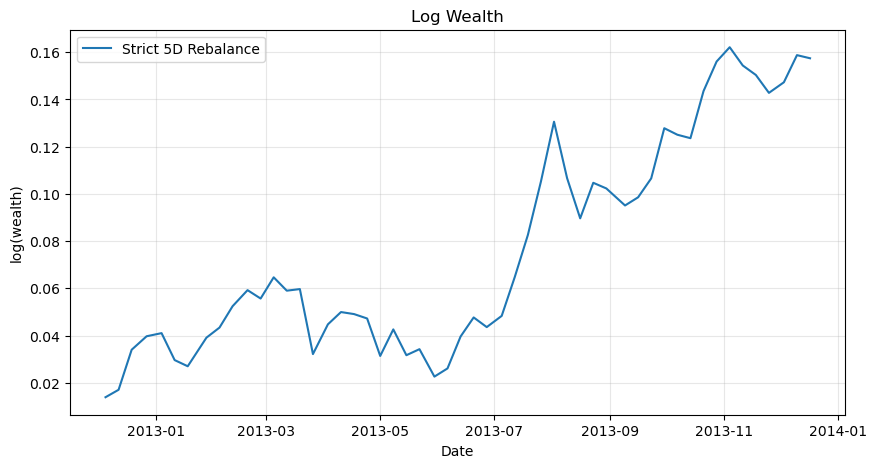

In [50]:
plot_log_wealth({
    'Strict 5D Rebalance': res_strict_5d,
})


hello